# Skin Cancer Detection — Training Pipeline

This notebook trains a binary CNN classifier to distinguish **benign** from **malignant**
skin lesions in dermoscopic images using transfer learning on EfficientNet-B0.

## Background

Melanoma accounts for less than 4% of skin cancers but approximately 75% of skin cancer
deaths (Shah et al., 2023). Early detection dramatically improves survival odds, but
traditional biopsy is painful, slow, and inaccessible in many regions.

Deep learning — specifically CNNs — have demonstrated strong performance on this task
because they learn spatial feature hierarchies from images: low-level edges at early layers,
textures at middle layers, and high-level patterns (asymmetry, irregular borders, color
variation) at deeper layers. These correspond directly to the clinical ABCD criteria
dermatologists use: Asymmetry, Border, Color, Diameter.

Shah et al. (2023) found CNN consistently outperforms standard ANN for image classification
tasks because ANN treats each pixel independently, losing spatial relationships.

## Sections
1. Setup
2. Load Dataset
3. Exploratory Data Analysis
4. Dataset and DataLoaders
5. Model
6. Phase 1 — Train Classifier Head
7. Phase 2 — Full Fine-Tuning
8. Evaluation
9. Save and Next Steps

## 1. Setup

In [23]:
import os, sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

sys.path.insert(0, str(Path('../app').resolve()))
from model import build_model, unfreeze_backbone, count_parameters, train_transform, val_transform

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {DEVICE}')
if DEVICE == 'cpu':
    print('Running on CPU. Training will be slow — consider Google Colab for a free GPU.')

Device: mps


## 2. Load Dataset

Download ISIC 2017 Task 3 from https://challenge.isic-archive.com/data/#2017

```
data/
├── ISIC-2017_Training_Data/          # .jpg dermoscopy images
└── ISIC-2017_Training_Part3_GroundTruth.csv
```

CSV columns: `image_id`, `melanoma` (1 = malignant), `seborrheic_keratosis`

In [24]:
DATA_DIR   = Path('../data')
IMAGE_DIR  = DATA_DIR / 'ISIC-2017_Training_Data'
LABELS_CSV = DATA_DIR / 'ISIC-2017_Training_Part3_GroundTruth.csv'

assert IMAGE_DIR.exists(),  f'Missing image directory: {IMAGE_DIR}'
assert LABELS_CSV.exists(), f'Missing labels CSV: {LABELS_CSV}'

df = pd.read_csv(LABELS_CSV)
df['label']      = df['melanoma'].astype(int)
df['label_name'] = df['label'].map({0: 'Benign', 1: 'Malignant'})

print(f'Total samples: {len(df)}')
print(df[['image_id', 'melanoma', 'label_name']].head(8))

Total samples: 2000
       image_id  melanoma label_name
0  ISIC_0000000       0.0     Benign
1  ISIC_0000001       0.0     Benign
2  ISIC_0000002       1.0  Malignant
3  ISIC_0000003       0.0     Benign
4  ISIC_0000004       1.0  Malignant
5  ISIC_0000006       0.0     Benign
6  ISIC_0000007       0.0     Benign
7  ISIC_0000008       0.0     Benign


## 3. Exploratory Data Analysis

Class distribution:
label_name
Benign       1626
Malignant     374

Imbalance ratio: 4.35:1 (benign:malignant)
This mirrors real-world prevalence. Handled with WeightedRandomSampler during training.
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


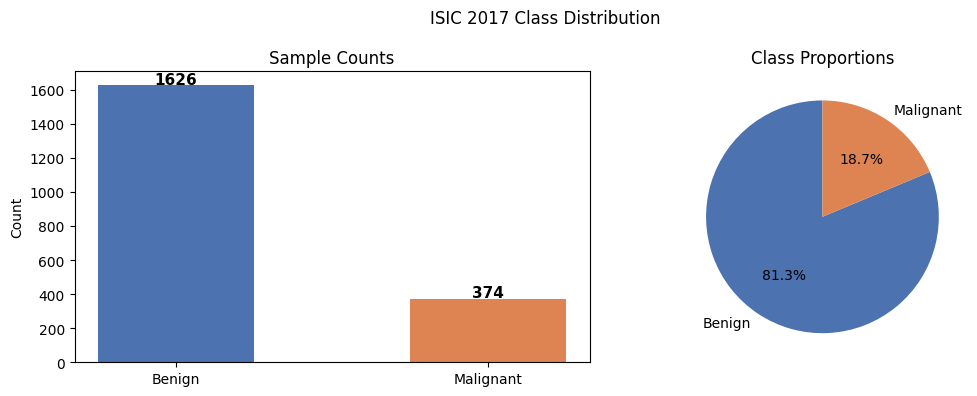

In [30]:
counts = df['label_name'].value_counts()
print('Class distribution:')
print(counts.to_string())
print(f'\nImbalance ratio: {counts["Benign"] / counts["Malignant"]:.2f}:1 (benign:malignant)')
print('This mirrors real-world prevalence. Handled with WeightedRandomSampler during training.')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('ISIC 2017 Class Distribution', fontsize=12)

axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'], width=0.5)
axes[0].set_ylabel('Count')
axes[0].set_title('Sample Counts')
for i, (label, count) in enumerate(counts.items()):
    axes[0].text(i, count + 8, str(count), ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

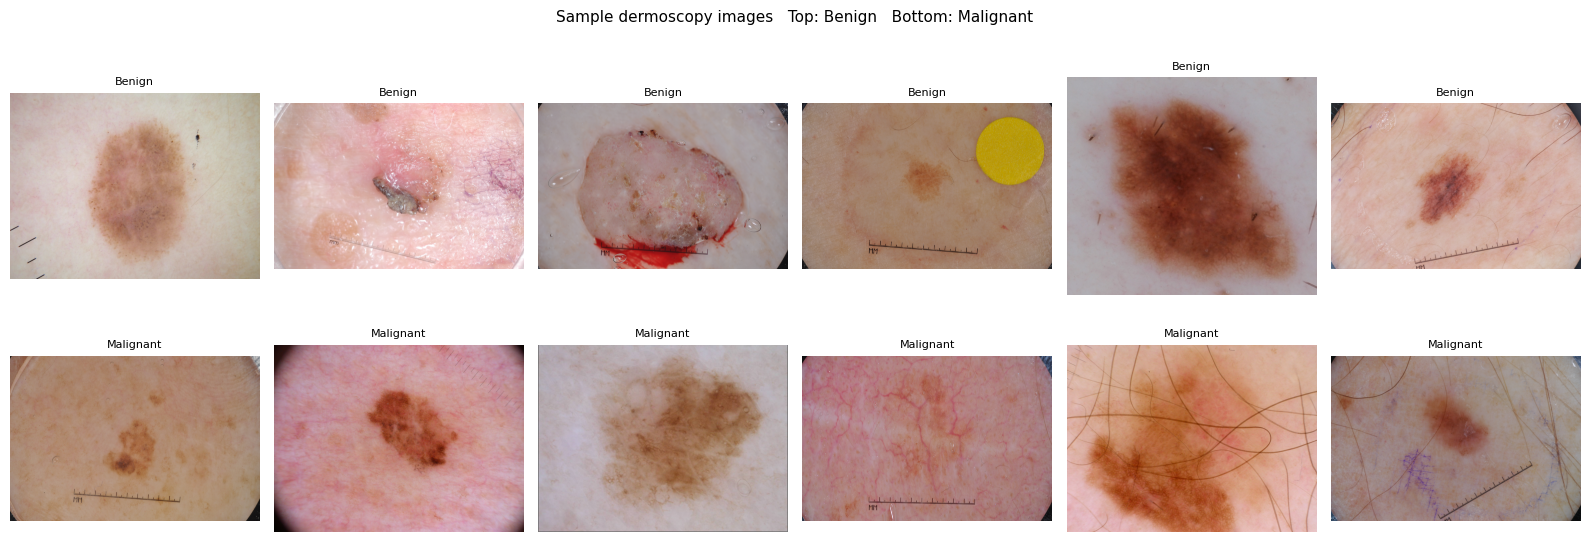

Look for: irregular/asymmetric borders, uneven pigmentation, and mixed colors in malignant lesions.


In [31]:
# Visual inspection of sample images
# Malignant lesions exhibit the ABCD criteria: Asymmetry, irregular Border,
# multiple Colors, and larger Diameter (Shah et al., 2023)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample dermoscopy images   Top: Benign   Bottom: Malignant', fontsize=11)

for label_val, row_axes in zip([0, 1], axes):
    samples = df[df['label'] == label_val].sample(6, random_state=SEED)
    for ax, (_, row) in zip(row_axes, samples.iterrows()):
        img = Image.open(IMAGE_DIR / f"{row['image_id']}.jpg")
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(row['label_name'], fontsize=8)

plt.tight_layout()
plt.show()
print('Look for: irregular/asymmetric borders, uneven pigmentation, and mixed colors in malignant lesions.')

## 4. Dataset and DataLoaders

### Data augmentation
Applied only to the training set. Random flips, rotations, and color jitter simulate
the variation seen in real photos (different cameras, lighting, angles). Augmentation
effectively expands the training set and reduces overfitting — a key technique for
small medical imaging datasets (Pham et al., 2018; Akinrinade & Du, 2025).

### WeightedRandomSampler
Compensates for the 4:1 class imbalance. Without this, the model can learn to always
predict Benign and achieve ~80% accuracy while being useless for detecting cancer.

In [32]:
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label']
)
print(f'Train: {len(train_df)} | Val: {len(val_df)}')
print('Train distribution:', train_df['label_name'].value_counts().to_dict())
print('Val distribution:  ', val_df['label_name'].value_counts().to_dict())

Train: 1600 | Val: 400
Train distribution: {'Benign': 1301, 'Malignant': 299}
Val distribution:   {'Benign': 325, 'Malignant': 75}


In [33]:
class SkinLesionDataset(Dataset):
    """
    Loads ISIC dermoscopy images on demand.

    The pipeline follows the standard approach described in Shah et al. (2023):
    image acquisition -> preprocessing -> feature extraction via CNN layers -> classification.

    Returns (image_tensor [3, 224, 224], label int) per sample.
    """
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(self.image_dir / f"{row['image_id']}.jpg").convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])


train_dataset = SkinLesionDataset(train_df, IMAGE_DIR, transform=train_transform)
val_dataset   = SkinLesionDataset(val_df,   IMAGE_DIR, transform=val_transform)

# Weighted sampler
class_counts   = train_df['label'].value_counts().sort_index().values
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_df['label'].values]
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=0, pin_memory=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 50 | Val batches: 13


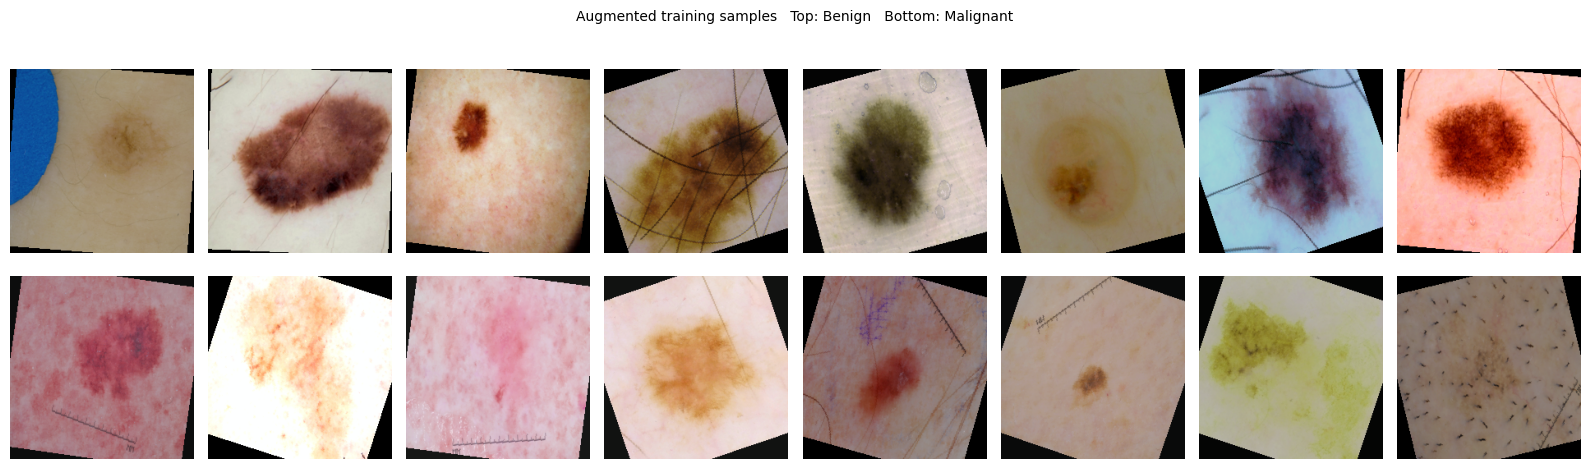

Each run of this cell produces different augmented versions of the same images.


In [34]:
# Visualize augmented training samples
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denorm(t):
    return np.clip(t.permute(1,2,0).numpy() * STD + MEAN, 0, 1)

imgs, lbls = next(iter(train_loader))
fig, axes  = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Augmented training samples   Top: Benign   Bottom: Malignant', fontsize=10)

for target, row_axes in zip([0, 1], axes):
    idxs = [i for i, l in enumerate(lbls.tolist()) if l == target][:8]
    for ax, i in zip(row_axes, idxs):
        ax.imshow(denorm(imgs[i]))
        ax.axis('off')
    for ax in row_axes[len(idxs):]:
        ax.axis('off')

plt.tight_layout()
plt.show()
print('Each run of this cell produces different augmented versions of the same images.')

## 5. Model

### Why transfer learning
Training a deep CNN from scratch on ~2000 ISIC images would overfit badly.
EfficientNet-B0 has already learned low-level features (edges, color gradients, textures)
from 1.2M ImageNet images. Transfer learning repurposes these features for dermoscopy
by replacing the classification head and fine-tuning.

### Two-phase training strategy
Directly fine-tuning all layers at once can corrupt the pretrained features with
random gradients from an untrained head.

Phase 1: Freeze the backbone. Train only the new head until it converges (~10 epochs).
Phase 2: Unfreeze everything. Fine-tune end-to-end at a lower learning rate.

This mirrors the approach used in Mahbod et al. and others surveyed in Akinrinade & Du (2025).

In [35]:
model  = build_model(freeze_backbone=True).to(DEVICE)
params = count_parameters(model)

print('EfficientNet-B0 with custom classification head')
print(f"  Total parameters:     {params['total']:>10,}")
print(f"  Trainable (phase 1):  {params['trainable']:>10,}  (classifier head only)")
print(f"  Frozen:               {params['frozen']:>10,}  (pretrained backbone)")

EfficientNet-B0 with custom classification head
  Total parameters:      4,729,342
  Trainable (phase 1):     721,794  (classifier head only)
  Frozen:                4,007,548  (pretrained backbone)


## 6. Phase 1 — Train Classifier Head (frozen backbone)

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

SAVE_PATH = Path('../app/best_model.pth')
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
print(f'Checkpoint will be saved to: {SAVE_PATH.resolve()}')

Checkpoint will be saved to: /Users/stevennguyen/skin-cancer-detector/app/best_model.pth


In [38]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = correct = total = 0
    for images, labels in tqdm(loader, leave=False, desc='train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_probs, all_labels = [], [], []
    for images, labels in tqdm(loader, leave=False, desc='val'):
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        total_loss    += criterion(outputs, labels).item() * len(labels)
        probs          = torch.softmax(outputs, dim=1)[:, 1]
        all_preds.extend(outputs.argmax(1).cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    n   = len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / n, acc, auc, all_preds, all_probs, all_labels

In [40]:
EPOCHS_P1 = 10
best_auc  = 0.0
history   = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'val_auc']}

print('Phase 1: classifier head only (backbone frozen)')
print(f'{"Epoch":>5}  {"TrLoss":>8}  {"TrAcc":>7}  {"VlLoss":>8}  {"VlAcc":>7}  {"VlAUC":>7}')
print('-' * 55)

for epoch in range(1, EPOCHS_P1 + 1):
    tr_loss, tr_acc              = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc, vl_auc, *_ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(vl_auc)

    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc, vl_auc]):
        history[k].append(v)

    flag = ''
    if vl_auc > best_auc:
        best_auc = vl_auc
        torch.save(model.state_dict(), SAVE_PATH)
        flag = '  <- saved'

    print(f'{epoch:>5}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  {vl_loss:>8.4f}  {vl_acc:>7.4f}  {vl_auc:>7.4f}{flag}')

print(f'\nBest AUC phase 1: {best_auc:.4f}')

Phase 1: classifier head only (backbone frozen)
Epoch    TrLoss    TrAcc    VlLoss    VlAcc    VlAUC
-------------------------------------------------------


KeyboardInterrupt: 

## 7. Phase 2 — Full Fine-Tuning

In [41]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model = unfreeze_backbone(model)

params = count_parameters(model)
print(f"Trainable after unfreeze: {params['trainable']:,} / {params['total']:,}")
print('Using lower learning rate (1e-4) to avoid disrupting pretrained backbone weights.')

EPOCHS_P2  = 10
optimizer2 = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=EPOCHS_P2)

print(f'\nPhase 2: full fine-tuning ({EPOCHS_P2} epochs)')
print(f'{"Epoch":>5}  {"TrLoss":>8}  {"TrAcc":>7}  {"VlLoss":>8}  {"VlAcc":>7}  {"VlAUC":>7}')
print('-' * 55)

for epoch in range(1, EPOCHS_P2 + 1):
    tr_loss, tr_acc              = train_epoch(model, train_loader, optimizer2, criterion, DEVICE)
    vl_loss, vl_acc, vl_auc, *_ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler2.step()

    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc, vl_auc]):
        history[k].append(v)

    flag = ''
    if vl_auc > best_auc:
        best_auc = vl_auc
        torch.save(model.state_dict(), SAVE_PATH)
        flag = '  <- saved'

    print(f'{epoch:>5}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  {vl_loss:>8.4f}  {vl_acc:>7.4f}  {vl_auc:>7.4f}{flag}')

print(f'\nBest AUC overall: {best_auc:.4f}')

Trainable after unfreeze: 4,729,342 / 4,729,342
Using lower learning rate (1e-4) to avoid disrupting pretrained backbone weights.

Phase 2: full fine-tuning (10 epochs)
Epoch    TrLoss    TrAcc    VlLoss    VlAcc    VlAUC
-------------------------------------------------------


    1    0.5409   0.7350    0.4802   0.7575   0.7820  <- saved


    2    0.4838   0.7575    0.4343   0.7900   0.8195  <- saved


    3    0.4415   0.7981    0.4687   0.7725   0.8182


    4    0.4288   0.7975    0.4222   0.8100   0.8187


...

    6    0.3606   0.8256    0.4777   0.8100   0.8032


    7    0.3641   0.8369    0.4610   0.8175   0.8062


    8    0.3647   0.8400    0.4579   0.8225   0.8061


    9    0.3194   0.8625    0.4670   0.8150   0.8091


   10    0.3312   0.8531    0.4623   0.8150   0.8089

Best AUC overall: 0.8213


## 8. Evaluation

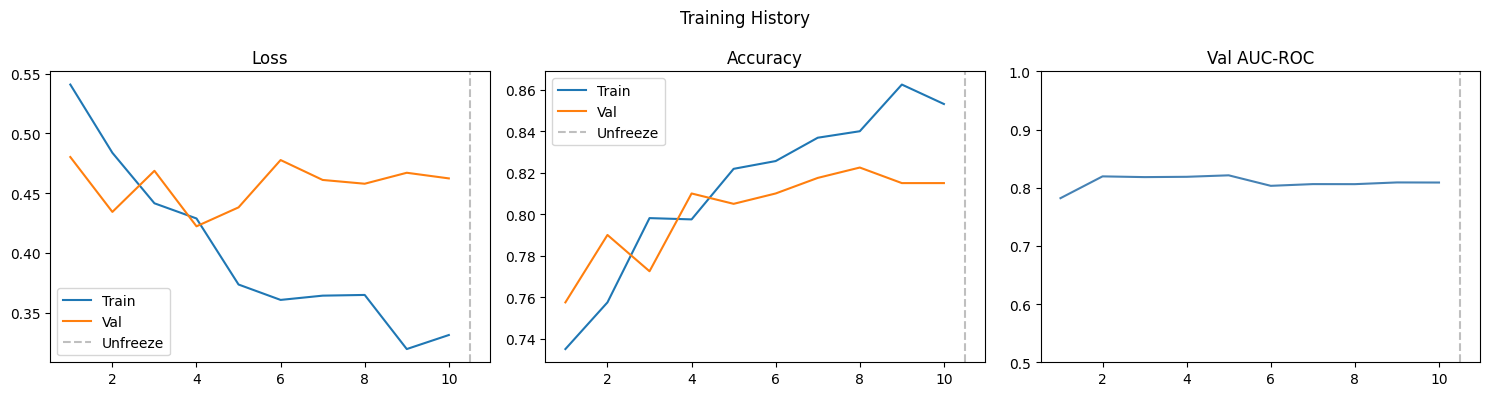

The dashed line marks where the backbone was unfrozen (phase 2 start).
You should see further improvement after this point.


In [43]:
total_e = len(history['train_loss'])
ep      = range(1, total_e + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training History', fontsize=12)

for ax, train_key, val_key, title in [
    (axes[0], 'train_loss', 'val_loss',  'Loss'),
    (axes[1], 'train_acc',  'val_acc',   'Accuracy'),
]:
    ax.plot(ep, history[train_key], label='Train')
    ax.plot(ep, history[val_key],   label='Val')
    ax.axvline(EPOCHS_P1 + 0.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze')
    ax.set_title(title)
    ax.legend()

axes[2].plot(ep, history['val_auc'], color='steelblue')
axes[2].axvline(EPOCHS_P1 + 0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Val AUC-ROC')
axes[2].set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()
print('The dashed line marks where the backbone was unfrozen (phase 2 start).')
print('You should see further improvement after this point.')

In [44]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
_, val_acc, val_auc, preds, probs, labels = evaluate(model, val_loader, criterion, DEVICE)

print('Final evaluation — validation set')
print('=' * 42)
print(f'Accuracy : {val_acc:.4f}')
print(f'AUC-ROC  : {val_auc:.4f}')
print()
print(classification_report(labels, preds, target_names=['Benign', 'Malignant']))
print('Sensitivity = recall for Malignant class (how many cancers were caught)')
print('Specificity = recall for Benign class (how many benign lesions were correctly cleared)')

Final evaluation — validation set
Accuracy : 0.8050
AUC-ROC  : 0.8213

              precision    recall  f1-score   support

      Benign       0.91      0.85      0.88       325
   Malignant       0.48      0.63      0.55        75

    accuracy                           0.81       400
   macro avg       0.70      0.74      0.71       400
weighted avg       0.83      0.81      0.81       400

Sensitivity = recall for Malignant class (how many cancers were caught)
Specificity = recall for Benign class (how many benign lesions were correctly cleared)


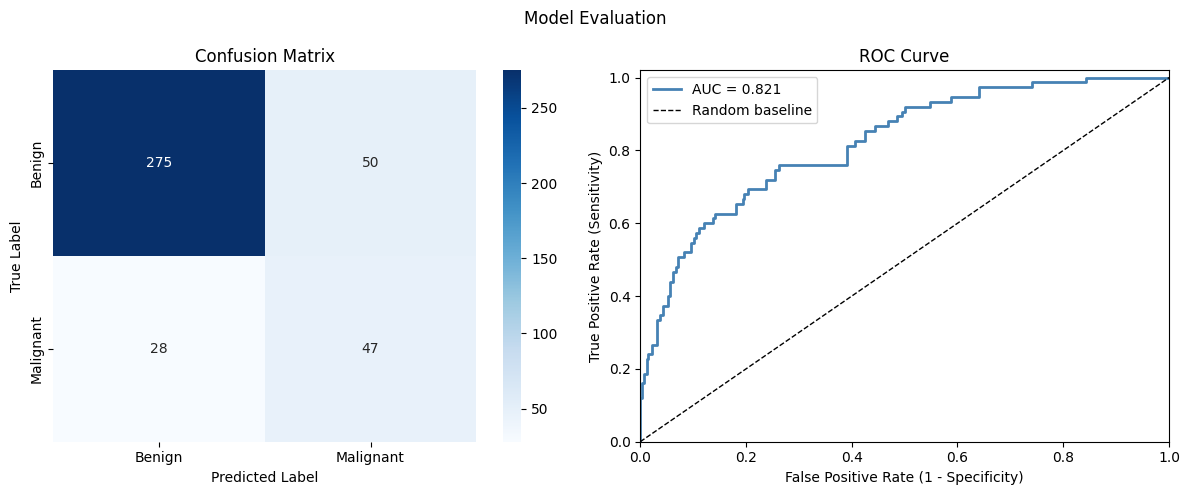

Saved to assets/evaluation.png


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Evaluation', fontsize=12)

# Confusion matrix
cm = confusion_matrix(labels, preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC curve
fpr, tpr, _ = roc_curve(labels, probs)
axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {val_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random baseline')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to assets/evaluation.png')

## 9. Save and Next Steps

In [46]:
size_mb = SAVE_PATH.stat().st_size / 1e6
print('Training complete.')
print(f'  Checkpoint : {SAVE_PATH.resolve()}')
print(f'  File size  : {size_mb:.1f} MB')
print(f'  Best AUC   : {best_auc:.4f}')
print(f'  Val Acc    : {val_acc:.4f}')
print()
print('Next steps:')
print('  1. Copy accuracy and AUC into the Results table in README.md')
print('  2. Run: python app/app.py  to test the web interface locally')
print('  3. Deploy to Hugging Face Spaces for a live demo link')

Training complete.
  Checkpoint : /Users/stevennguyen/skin-cancer-detector/app/best_model.pth
  File size  : 19.2 MB
  Best AUC   : 0.8213
  Val Acc    : 0.8050

Next steps:
  1. Copy accuracy and AUC into the Results table in README.md
  2. Run: python app/app.py  to test the web interface locally
  3. Deploy to Hugging Face Spaces for a live demo link
